In [1]:
import os
os.chdir('../..')

In [25]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import numpy as np
import polars as pl

from src.descriptors import SOAPDescriptor, ACSFDescriptor
from src.clusters import ClusterAnalysis
from src.datasets import QM9Dataset

In [3]:
loader = QM9Dataset()
loader.load()
soap = SOAPDescriptor(loader, r_cut=6.0, n_max=8)
soap.compute()

2026-02-11 11:31:24.473 | INFO     | src.datasets:load:67 - Loading QM9 from data/QM9/dataset_cleaned.csv...
2026-02-11 11:31:24.555 | INFO     | src.descriptors:compute:43 - Computing SOAP (rcut=6.0, nmax=8)...
2026-02-11 11:31:26.246 | SUCCESS  | src.descriptors:compute:77 - SOAP computed. Loader now contains 'soap_embedding' column.


In [4]:
soap.loader.df

mol_id,canonical_smiles,selfies,num_atoms,structure_class,mol_weight,logp,tpsa,num_heavy_atoms,num_rings,num_aromatic_rings,num_rotatable_bonds,fraction_csp3,h_bond_donors,h_bond_acceptors,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,soap_embedding
str,str,str,i64,str,f64,f64,f64,i64,i64,i64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[f64]
"""qm9_0""","""C""","""[C]""",5,"""Acyclic""",16.043,0.6361,0.0,1,0,0,0,1.0,0,0,0.0,13.21,-10.549854,3.186453,13.736308,35.364101,1.217682,-1101.487793,-1101.40979,-1101.384033,-1102.022949,6.469,-17.172182,-17.286823,-17.389656,-16.151918,157.711807,157.709976,157.706985,"[0.128333, 0.343412, … 0.0]"
"""qm9_1""","""N""","""[N]""",4,"""Acyclic""",17.031,0.162,35.0,1,0,0,0,0.0,1,1,1.6256,9.46,-6.993326,2.255824,9.249149,26.1563,0.934929,-1538.147705,-1538.069824,-1538.044189,-1538.666748,6.316,-12.005855,-12.082129,-12.159273,-11.246005,293.609741,293.541107,191.393967,"[0.11413, 0.311847, … 0.0]"
"""qm9_2""","""O""","""[O]""",3,"""Acyclic""",18.015,-0.8247,31.5,1,0,0,0,0.0,0,0,1.8511,6.31,-7.967494,1.869422,9.836916,19.0002,0.581643,-2079.077881,-2079.000732,-2078.975098,-2079.558105,6.002,-9.240362,-9.278811,-9.330214,-8.733849,799.588135,437.90387,282.945465,"[0.092132, 0.26219, … 0.0]"
"""qm9_3""","""C#C""","""[C][#C]""",4,"""Acyclic""",26.038,0.2494,0.0,2,0,0,0,0.0,0,0,0.0,16.280001,-7.741639,1.376896,9.118535,59.524799,0.730381,-2103.669434,-2103.590576,-2103.564697,-2104.186523,8.574,-16.716963,-16.792231,-16.869347,-15.862634,0.0,35.610035,35.610035,"[0.051121, 0.1485, … 0.0]"
"""qm9_4""","""C#N""","""[C][#N]""",3,"""Acyclic""",27.026,0.13978,23.79,2,0,0,0,0.0,0,1,2.8937,12.99,-9.806983,0.519737,10.329442,48.747601,0.451736,-2541.866943,-2541.79834,-2541.772705,-2542.393555,6.278,-13.088188,-13.13529,-13.186666,-12.520096,0.0,44.593884,44.593884,"[0.022724, 0.066516, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""qm9_2010""","""O=C1C=CCCN1""","""[O][=C][C][=C][C][C][N][Ring1]…",14,"""Aliphatic Ring""",97.117,0.0625,29.1,7,1,0,0,0.4,1,1,4.175,59.880001,-6.511684,-0.854437,5.657247,680.8172,3.166589,-8833.507812,-8833.344727,-8833.319336,-8834.314453,22.622999,-60.986275,-61.363506,-61.697636,-56.969707,5.0588,2.61575,1.79821,"[0.050044, 0.144033, … 0.0]"
"""qm9_2011""","""O=C1C=CCCO1""","""[O][=C][C][=C][C][C][O][Ring1]…",13,"""Aliphatic Ring""",98.101,0.4895,26.3,7,1,0,0,0.4,0,2,4.8544,56.209999,-7.159316,-1.257166,5.90215,655.236389,2.820787,-9374.298828,-9374.142578,-9374.116211,-9375.104492,21.473,-58.082684,-58.426769,-58.735184,-54.355564,5.15103,2.69583,1.85565,"[0.042514, 0.122175, … 0.0]"
"""qm9_2012""","""[NH-][C@H]1CCCCO1""","""[NH1-1][C@H1][C][C][C][C][O][R…",16,"""Aliphatic Ring""",100.141,1.5652,33.03,7,1,0,0,1.0,0,1,3.2084,62.029999,-6.908971,0.634025,7.542996,719.927979,3.796587,-8865.521484,-8865.349609,-8865.324219,-8866.344727,23.990999,-65.773956,-66.218506,-66.604065,-61.192863,4.58056,2.56496,1.77558,"[0.068614, 0.197251, … 0.0]"


In [5]:
def analyze_soap_sensitivity(loader, r_cuts=[float(i) for i in range(2, 9)]):
    """
    Runs the Grassmann Stress Test using SOAP with different cutoff radii
    to see how 'resolution' affects clustering performance.
    """
    frames = loader.run_stress_test()
    true_labels = [f.info['mol_id'] for f in frames]
    n_clusters = len(set(true_labels))
    
    ari_scores = []
    
    print("--- SOAP Sensitivity Analysis (Tuning r_cut) ---")
    
    for r in r_cuts:
        soap_desc = SOAPDescriptor(loader, r_cut=r, n_max=8, l_max=6)
        
        features = []
        for frame in frames:
            vec = soap_desc.soap.create(frame).flatten()
            features.append(vec)
        
        X = np.array(features)
        
        # Cluster
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        preds = kmeans.fit_predict(X)
        
        # Score
        score = adjusted_rand_score(true_labels, preds)
        ari_scores.append(score)
        print(f"r_cut = {r:.1f} Å -> ARI = {score:.4f}")

    # Plot results
    plt.figure(figsize=(8, 5))
    plt.plot(r_cuts, ari_scores, marker='o', linestyle='-', color='b')
    plt.axvline(x=6.0, color='r', linestyle='--', label='Target (6.0)')
    plt.title("Sensitivity of SOAP Descriptor to Cutoff Radius")
    plt.xlabel("Cutoff Radius ($r_{cut}$) [Å]")
    plt.ylabel("Clustering Performance (ARI)")
    plt.grid(True)
    plt.legend()
    plt.show()


--- SOAP Sensitivity Analysis (Tuning r_cut) ---
r_cut = 2.0 Å -> ARI = 0.9583
r_cut = 3.0 Å -> ARI = 1.0000
r_cut = 4.0 Å -> ARI = 1.0000
r_cut = 5.0 Å -> ARI = 1.0000
r_cut = 6.0 Å -> ARI = 1.0000
r_cut = 7.0 Å -> ARI = 1.0000
r_cut = 8.0 Å -> ARI = 1.0000


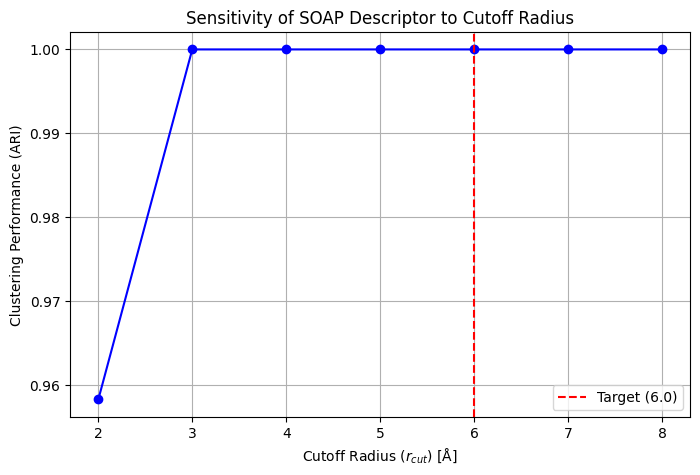

In [6]:
analyze_soap_sensitivity(loader)

# ACSF

In [7]:
acsf = ACSFDescriptor(loader, r_cut=6.0)

acsf.compute()

print(loader.df.select(["mol_id", "acsf_embedding"]).head(5))

2026-02-11 11:31:27.274 | INFO     | src.descriptors:compute:116 - Computing ACSF (rcut=6.0)...
2026-02-11 11:31:28.790 | SUCCESS  | src.descriptors:compute:155 - ACSF computed. Loader now contains 'acsf_embedding' column.


shape: (5, 2)
┌────────┬─────────────────────────────┐
│ mol_id ┆ acsf_embedding              │
│ ---    ┆ ---                         │
│ str    ┆ list[f64]                   │
╞════════╪═════════════════════════════╡
│ qm9_0  ┆ [2.638297, 1.725127, … 0.0] │
│ qm9_1  ┆ [1.912525, 1.422883, … 0.0] │
│ qm9_2  ┆ [1.179878, 1.01244, … 0.0]  │
│ qm9_3  ┆ [1.008822, 0.527104, … 0.0] │
│ qm9_4  ┆ [0.544152, 0.365345, … 0.0] │
└────────┴─────────────────────────────┘


# Clustering

In [8]:
cols = [
    "mol_weight", "logp", "tpsa", "num_heavy_atoms", "num_rings", 
    "num_aromatic_rings", "num_rotatable_bonds", "fraction_csp3", 
    "h_bond_donors", "h_bond_acceptors", "mu", "alpha", "homo", 
    "lumo", "gap", "r2", "zpve", "u0", "u", "h", "g", "cv"
]

loader.apply_scaling(cols, mode="fit_transform")

2026-02-11 11:31:28.799 | INFO     | src.datasets:apply_scaling:222 - Fitting and transforming columns: ['mol_weight', 'logp', 'tpsa', 'num_heavy_atoms', 'num_rings', 'num_aromatic_rings', 'num_rotatable_bonds', 'fraction_csp3', 'h_bond_donors', 'h_bond_acceptors', 'mu', 'alpha', 'homo', 'lumo', 'gap', 'r2', 'zpve', 'u0', 'u', 'h', 'g', 'cv']


--- Running KMEANS ---
Found 4 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.0917
Silhouette Score: 0.2411
Calinski-Harabasz Score: 1445.7624


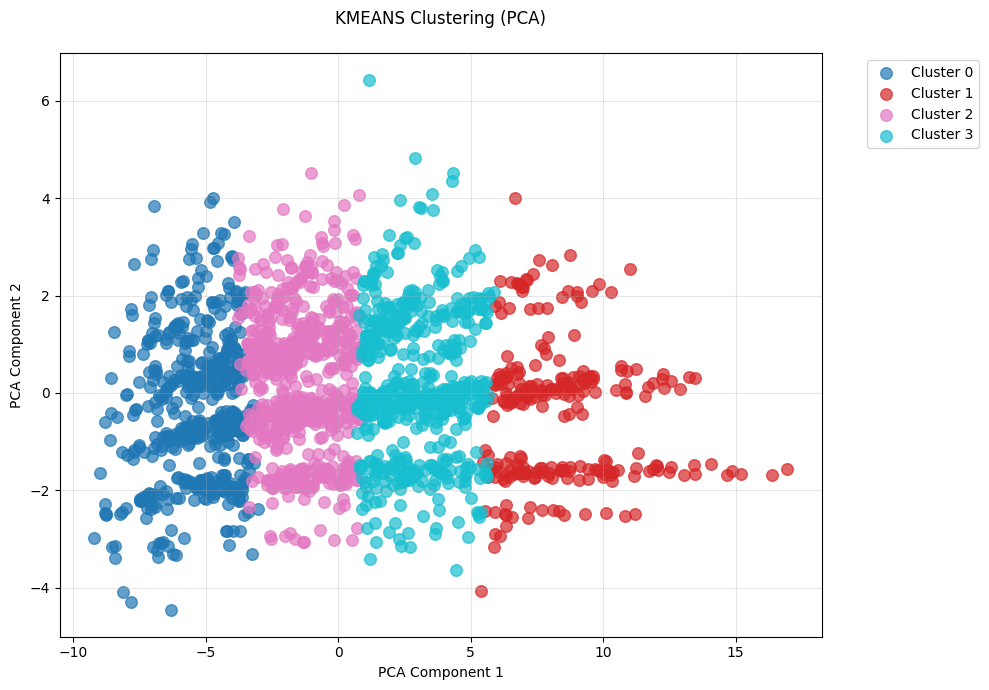

Finding top 3 neighbors for every molecule...
Found 927 mismatches.
--- Running KMEANS ---
Found 4 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.0917
Silhouette Score: 0.2411
Calinski-Harabasz Score: 1445.7624


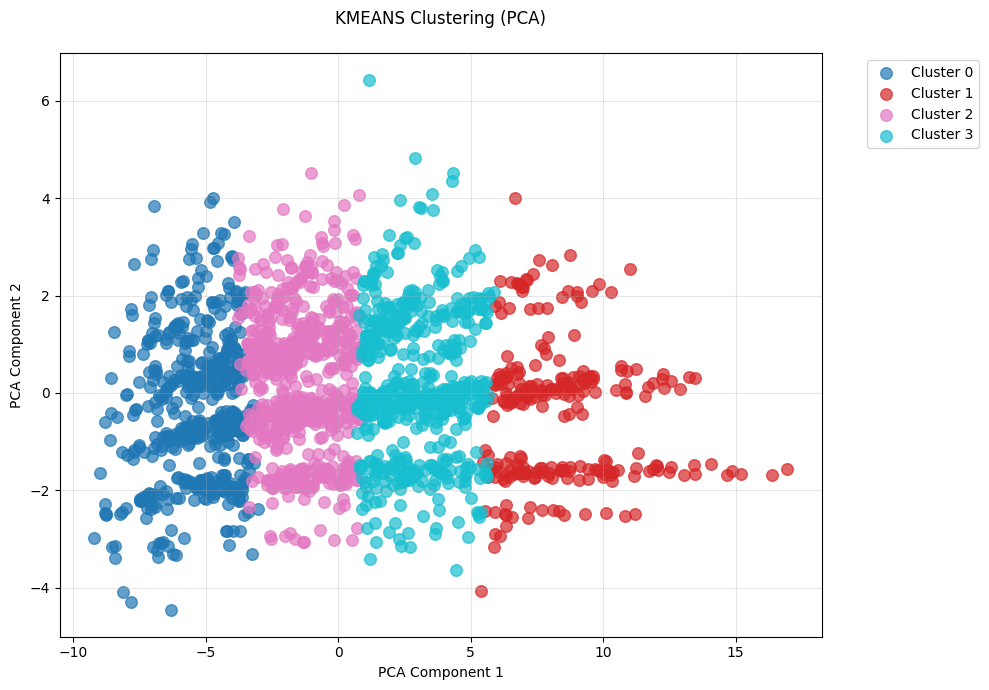

Finding top 3 neighbors for every molecule...
Found 927 mismatches.
--- Running KMEANS ---
Found 4 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.0917
Silhouette Score: 0.2411
Calinski-Harabasz Score: 1445.7624


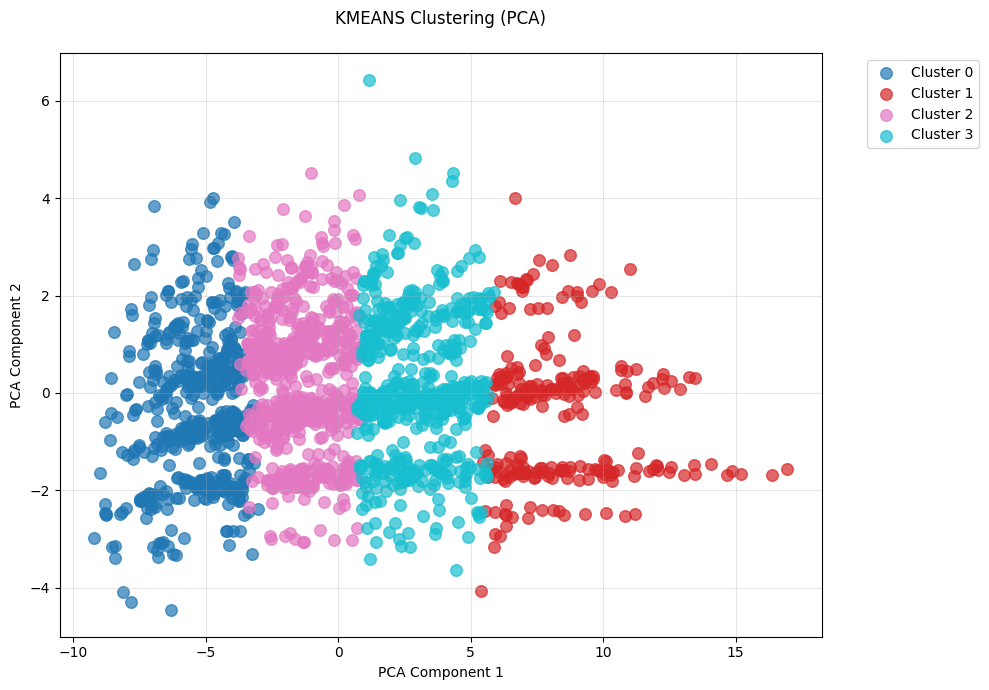

Finding top 3 neighbors for every molecule...
Found 927 mismatches.
--- Running KMEANS ---
Found 4 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.0917
Silhouette Score: 0.2411
Calinski-Harabasz Score: 1445.7624


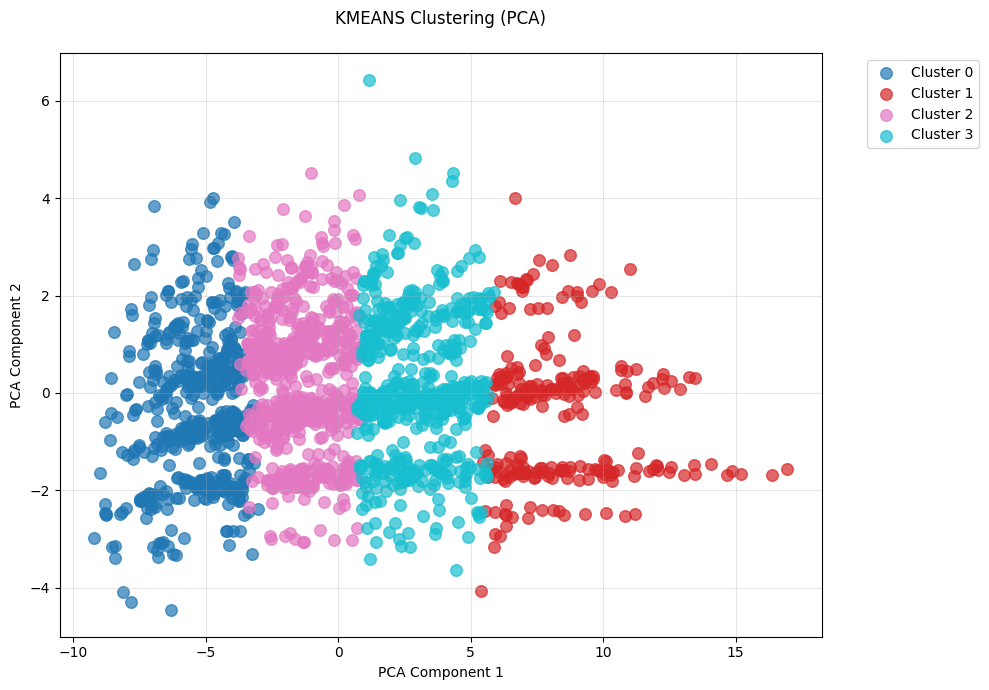

Finding top 3 neighbors for every molecule...
Found 927 mismatches.
--- Running KMEANS ---
Found 4 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.0917
Silhouette Score: 0.2411
Calinski-Harabasz Score: 1445.7624


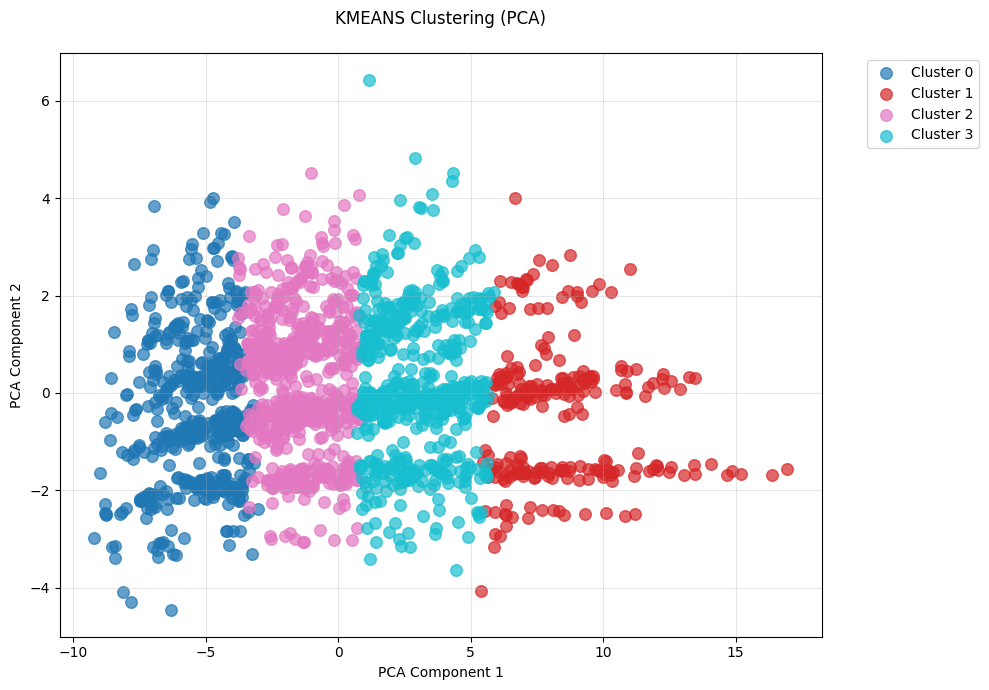

Finding top 3 neighbors for every molecule...
Found 927 mismatches.
--- Running KMEANS ---
Found 4 clusters (excluding noise).
Adjusted Rand Index (Ground Truth): 0.0917
Silhouette Score: 0.2411
Calinski-Harabasz Score: 1445.7624


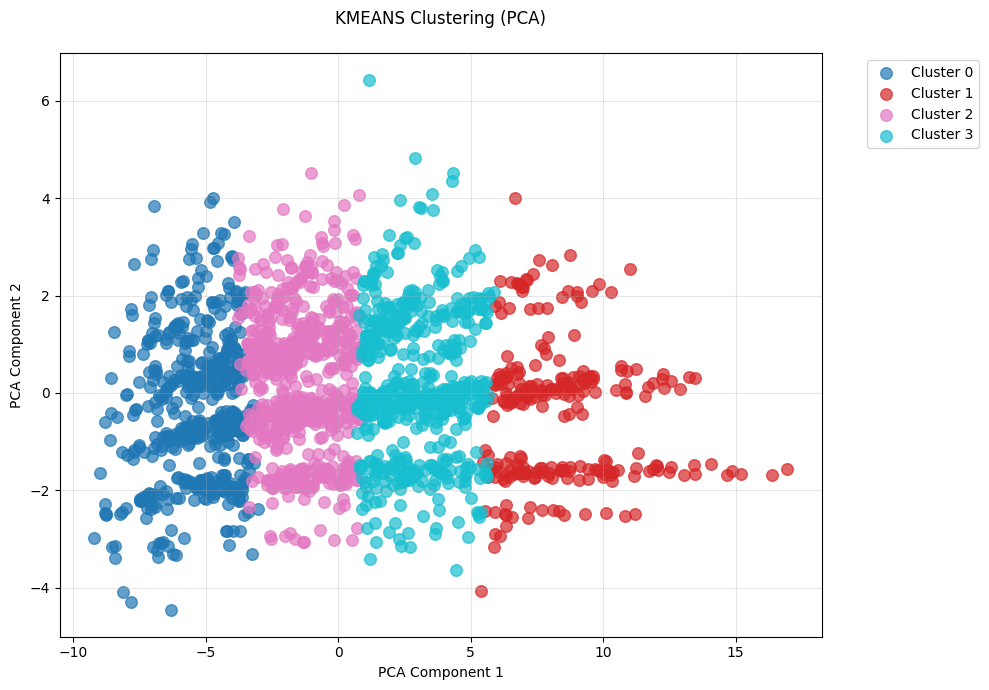

Finding top 3 neighbors for every molecule...
Found 927 mismatches.


In [41]:
embeddings = ['soap_embedding','acsf_embedding']
methods = ['kmeans', 'hierachical', 'dbscan']

for embedding in embeddings:
    for method in methods:

        df_clean = loader.df.filter(pl.col("soap_embedding").is_not_null())
        X_soap = np.array(df_clean["soap_embedding"].to_list())
        analyzer = ClusterAnalysis(X_soap, 
                                true_labels=df_clean["structure_class"], 
                                meta_df=df_clean)
        analyzer.run(method='kmeans', n_clusters=4)
        analyzer.evaluate()
        analyzer.plot_pca()
        misclassification_report = analyzer.get_misclassification_report()
        save_path = f'results/cluster_reports/{embedding}/cluster_outlier_report_{method}.csv'
        misclassification_report.write_csv(save_path)

mol_id,canonical_smiles,True_Class,Assigned_Cluster,Cluster_Dominant_Class,Closest_Neighbors_Info
str,str,str,i32,str,str
"""qm9_1""","""N""","""Acyclic""",0,"""Aromatic""","""qm9_19 (NC(N)=O) || qm9_11 (NC…"
"""qm9_2""","""O""","""Acyclic""",0,"""Aromatic""","""qm9_5 (C=O) || qm9_11 (NC=O) |…"
"""qm9_3""","""C#C""","""Acyclic""",0,"""Aromatic""","""qm9_25 (C#CC=O) || qm9_112 (CC…"
"""qm9_4""","""C#N""","""Acyclic""",0,"""Aromatic""","""qm9_26 (N#CC=O) || qm9_169 (c1…"
"""qm9_5""","""C=O""","""Acyclic""",0,"""Aromatic""","""qm9_33 (N#CCO) || qm9_36 (COC=…"
…,…,…,…,…,…
"""qm9_1629""","""CC[C@@H](O)C(N)=O""","""Acyclic""",3,"""Aliphatic Ring""","""qm9_1097 (C[C@@H](O)CC(N)=O) |…"
"""qm9_1630""","""CCN(C)C(C)=O""","""Acyclic""",3,"""Aliphatic Ring""","""qm9_1613 (CCC(=O)N(C)C) || qm9…"
"""qm9_1631""","""CCN(C)C(N)=O""","""Acyclic""",3,"""Aliphatic Ring""","""qm9_1093 (CC(C)NC(N)=O) || qm9…"
